# Random Forest — Phase 3

**Phase 3 scope: Random Forest only.** XGBoost is deferred to a later pass in this same phase
(not implemented in this notebook, per this task's explicit scope). SHAP-based explainability is
deferred to Phase 4. Findings get written up separately in `PHASE3_FINDINGS.md`.

One variant is trained here:

- **PRIMARY** — `RandomForestClassifier(class_weight='balanced')`, consistent with the
  class-weighting-first approach used for the Logistic Regression baseline in Phase 2.

**On SMOTE:** Phase 2 found SMOTE-resampled Logistic Regression (PR-AUC 0.6102) meaningfully
outperformed `class_weight='balanced'` Logistic Regression (PR-AUC 0.5087). Whether that same
comparison is worth repeating for Random Forest is **deferred to the model-comparison notebook**,
once Random Forest, XGBoost, and both Phase 2 variants can all be looked at side by side — running
it here in isolation would just be redone there. See the one-line note again near the results
below.

Uses the same leakage-safe feature pipeline (`ml/src/preprocessing.py`) and the same chronological
split (`ml/src/split.py`, adjusted cutoff) as Phase 2, so results are directly comparable.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

### Load data and import the project's own preprocessing/split modules

Same repo-root-finding pattern as `01_eda.ipynb` / `02_baseline_model.ipynb`, and `ml/src` is
added to `sys.path` so this notebook imports the actual `preprocessing.py` / `split.py` modules
rather than duplicating their logic.

In [ ]:
def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / ".git").exists() or (parent / ".repo-root").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (looked for .git or .repo-root)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "ml" / "src"))

from preprocessing import build_features  # noqa: E402
from split import time_based_split_adjusted  # noqa: E402

raw_csv = next((REPO_ROOT / "ml" / "data" / "raw").glob("*.csv"))
df = pd.read_csv(raw_csv)
print(f"Loaded {raw_csv.name}: {df.shape[0]:,} rows")

## Split used

Same **adjusted** cutoff as Phase 2 (`time_based_split_adjusted`, step ≤ 575) — excludes PaySim's
fully degenerate day 30 (100% fraud, zero legitimate transactions) from both splits. See
`CLAUDE.md` ("Time-Based Split Methodology") for the full rationale; not re-derived here since
Phase 2 already established and tested it. The residual ~9.5x train/test fraud-rate skew from the
gradual legitimate-volume decline in days 17-29 applies here too.

In [3]:
train_df, test_df, cutoff_used = time_based_split_adjusted(df)
print(f"Adjusted cutoff: step <= {cutoff_used}")
print(f"train: {len(train_df):,} rows, {train_df['isFraud'].sum():,} fraud "
      f"({train_df['isFraud'].mean():.4%})")
print(f"test:  {len(test_df):,} rows, {test_df['isFraud'].sum():,} fraud "
      f"({test_df['isFraud'].mean():.4%})")

Adjusted cutoff: step <= 575
train: 6,200,317 rows, 6,359 fraud (0.1026%)
test:  162,021 rows, 1,572 fraud (0.9702%)


## Feature engineering — split first, transform second

Same `build_features()` call, applied separately to `train_df` and `test_df`, as Phase 2.

In [4]:
X_train, y_train, feature_columns = build_features(train_df)
X_test, y_test, _ = build_features(test_df)

# one-hot / boolean columns -> float, for sklearn compatibility
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(f"X_train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"X_test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")
print(f"\nFeature columns: {feature_columns}")

X_train: (6200317, 12), fraud rate 0.1026%
X_test:  (162021, 12), fraud rate 0.9702%

Feature columns: ['oldbalanceOrg', 'oldbalanceDest', 'amount', 'hour_of_day', 'day_of_week', 'amount_to_balance_ratio', 'is_merchant_dest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## Random Forest (PRIMARY): `class_weight='balanced'`

**Starting hyperparameters, not a tuned final model.** `n_estimators=200` and `max_depth=12` are
reasonable first-pass choices — enough trees for a stable ensemble, and a depth bound that lets
the forest capture nonlinear/interaction signal (which Logistic Regression structurally can't)
without growing fully unbounded trees on 6.2M rows. No grid search in this pass; a proper
hyperparameter sweep is left for a later tuning pass once Random Forest, XGBoost, and the Phase 2
baselines can be compared side by side.

`class_weight='balanced'` mirrors the Phase 2 "class-weighting-first" approach — Random Forest
supports it natively (reweights the impurity criterion per class, same idea as reweighting the
loss in Logistic Regression), so no resampling is needed for this primary run.

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

proba_rf = rf.predict_proba(X_test)[:, 1]
pr_auc_rf = average_precision_score(y_test, proba_rf)
print(f"PR-AUC (RandomForest, class_weight='balanced'): {pr_auc_rf:.6f}")

PR-AUC (RandomForest, class_weight='balanced'): 0.999963


**Note on SMOTE (deferred, as flagged above):** not re-run here. Phase 2's SMOTE-vs-balanced
comparison lives in `BASELINE_FINDINGS.md`; whether it's worth repeating for Random Forest is
deferred to the model-comparison notebook where all variants (LR-balanced, LR-SMOTE, RF-balanced,
RF-SMOTE, XGBoost, ...) can be judged together rather than piecemeal per model.

## PR-AUC vs. Phase 2

Same headline metric as Phase 2, same reasoning for why (accuracy is meaningless at this fraud
rate; ROC-AUC is misleading given the ~100:1 class imbalance in the test set) — see
`BASELINE_FINDINGS.md` for the full argument, not repeated here.

In [6]:
print("PR-AUC comparison (all evaluated on the identical adjusted test set):")
print(f"  Phase 2 - LogisticRegression(class_weight='balanced'): 0.5087")
print(f"  Phase 2 - LogisticRegression + SMOTE (0.1 ratio):      0.6102")
print(f"  Phase 3 - RandomForest(class_weight='balanced'):       {pr_auc_rf:.6f}")

PR-AUC comparison (all evaluated on the identical adjusted test set):
  Phase 2 - LogisticRegression(class_weight='balanced'): 0.5087
  Phase 2 - LogisticRegression + SMOTE (0.1 ratio):      0.6102
  Phase 3 - RandomForest(class_weight='balanced'):       0.999963


## Precision-recall curve

Same no-skill baseline convention as Phase 2 (test-set fraud rate, ~0.97%).

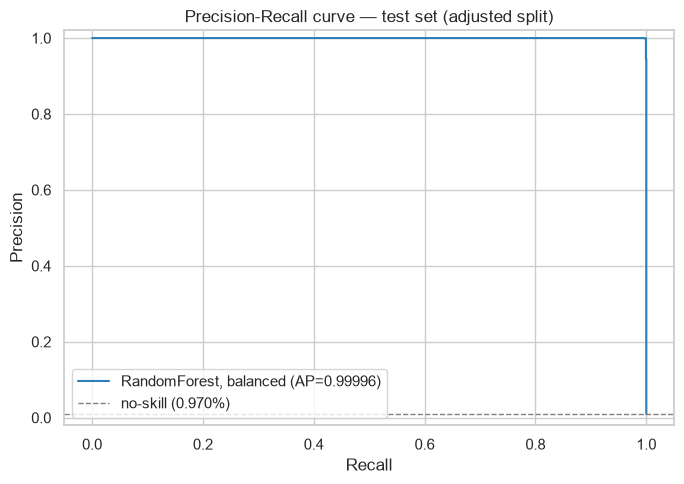

In [7]:
precision_rf, recall_rf, _ = precision_recall_curve(y_test, proba_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_rf, precision_rf, label=f"RandomForest, balanced (AP={pr_auc_rf:.5f})", color="#2c7fb8")
ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, label=f"no-skill ({y_test.mean():.3%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve — test set (adjusted split)")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Confusion matrices across candidate thresholds

Default 0.5 plus three others (0.1, 0.3, 0.7), same illustrative-only framing as Phase 2 — formal
threshold selection for the demo/dashboard is still deferred.

In [8]:
THRESHOLDS = [0.1, 0.3, 0.5, 0.7]


def threshold_table(y_true, proba, thresholds=THRESHOLDS):
    rows = []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        rows.append(
            {
                "threshold": t,
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "TN": tn,
                "precision": precision_score(y_true, preds, zero_division=0),
                "recall": recall_score(y_true, preds, zero_division=0),
                "f1": f1_score(y_true, preds, zero_division=0),
            }
        )
    return pd.DataFrame(rows)


print("RandomForest, class_weight='balanced':")
table_rf = threshold_table(y_test, proba_rf)
display(table_rf)

RandomForest, class_weight='balanced':


,threshold,TP,FP,FN,TN,precision,recall,f1
0,0.1,1572,888,0,159561,0.639024,1.000000,0.779762
1,0.3,1571,28,1,160421,0.982489,0.999364,0.990855
2,0.5,1571,2,1,160447,0.998729,0.999364,0.999046
3,0.7,1567,1,5,160448,0.999362,0.996819,0.998089


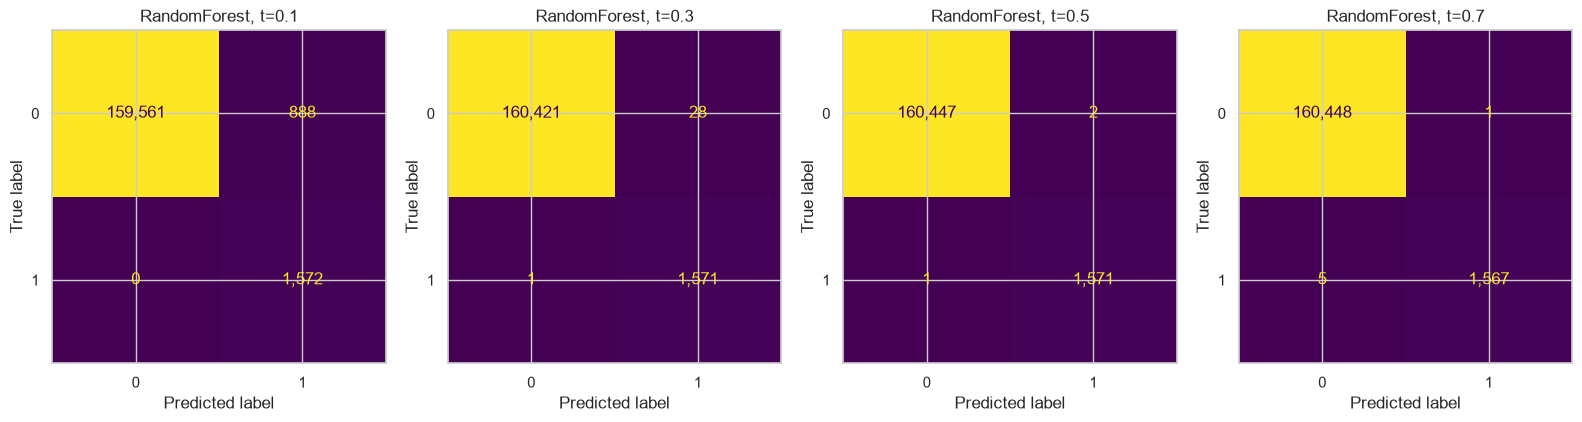

In [9]:
fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(4 * len(THRESHOLDS), 4))

for col, t in enumerate(THRESHOLDS):
    preds_rf = (proba_rf >= t).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds_rf)).plot(
        ax=axes[col], colorbar=False, values_format=","
    )
    axes[col].set_title(f"RandomForest, t={t}")

plt.tight_layout()
plt.show()

## Why PR-AUC is this high, and why that's not a bug

The PR-AUC above (~0.99996) is dramatically higher than either Phase 2 Logistic Regression variant
(0.5087 / 0.6102) — high enough that it's worth checking *why* before trusting it, rather than just
reporting the number.

The driver is `amount_to_balance_ratio`. It is **not leakage** — it's built only from
`amount` and `oldbalanceOrg`, both known before the transaction executes (see
`preprocessing.py` / `CLAUDE.md`) — but PaySim's fraud-generation logic makes it an extremely
strong signal: fraudulent transactions are simulated as draining the origin account, i.e.
`amount ≈ oldbalanceOrg`, which pushes `amount_to_balance_ratio` to **≈1.0** almost every time.
Legitimate transactions don't follow this pattern, so their ratio is scattered across many orders
of magnitude with no such concentration.

The catch: this is a **non-monotonic** signal — "ratio is close to 1" is a narrow band, not "ratio
is high" or "ratio is low" — which is exactly the kind of pattern a linear model (Logistic
Regression) structurally cannot express as a single coefficient, but a tree ensemble can carve out
directly with a couple of threshold splits. That's the most direct explanation for why Random
Forest jumps this far above both Phase 2 variants: it isn't "smarter" in a general sense here, it's
specifically able to exploit a narrow-band pattern the linear model's functional form can't
reach. This is checked quantitatively in the feature-importance section below, and
`amount_to_balance_ratio` does come out on top there too.

In [10]:
print("amount_to_balance_ratio by class (test set):")
display(X_test["amount_to_balance_ratio"].groupby(y_test).describe())

from sklearn.metrics import average_precision_score as _aps
single_feature_ap = _aps(y_test, X_test["amount_to_balance_ratio"])
print(f"\nSingle-feature PR-AUC using raw amount_to_balance_ratio as a score: {single_feature_ap:.4f}")
print("(Low despite being the top feature-importance driver below -- confirms the signal is")
print(" non-monotonic (a narrow band near 1.0), not 'higher ratio = more fraud'; a raw linear")
print(" score on this feature is a poor classifier by itself, but a tree can split around the")
print(" band directly.)")

amount_to_balance_ratio by class (test set):


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,160449.0,51216.312114,286015.198694,0.000001,0.195820,3.954001,3594.100000,15415938.31
1,1572.0,0.985472,0.097886,0.000000,0.999991,0.999998,0.999999,1.00



Single-feature PR-AUC using raw amount_to_balance_ratio as a score: 0.0078
(Low despite being the top feature-importance driver below -- confirms the signal is
 non-monotonic (a narrow band near 1.0), not 'higher ratio = more fraud'; a raw linear
 score on this feature is a poor classifier by itself, but a tree can split around the
 band directly.)


## Feature importances (built-in, not SHAP)

Mean decrease in impurity, `RandomForestClassifier`'s default `feature_importances_`. SHAP-based
explainability (which handles correlated/collinear features more rigorously than impurity-based
importance) is deferred to Phase 4 — this is a first-pass sanity check against EDA expectations,
not the final explainability story.

,importance
amount_to_balance_ratio,0.435554
oldbalanceOrg,0.131322
amount,0.087892
type_CASH_IN,0.065726
type_PAYMENT,0.061314
type_TRANSFER,0.059499
is_merchant_dest,0.052251
type_CASH_OUT,0.043243
oldbalanceDest,0.034401
hour_of_day,0.026996


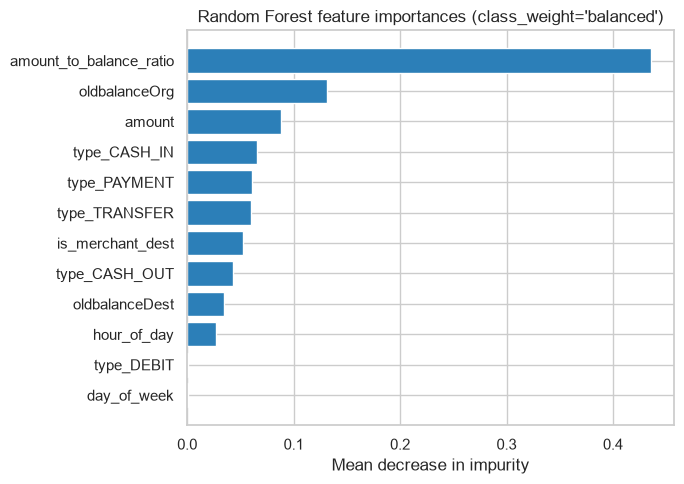

In [11]:
importances = (
    pd.Series(rf.feature_importances_, index=feature_columns, name="importance")
    .sort_values(ascending=False)
)
display(importances.to_frame())

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importances.index, importances.values, color="#2c7fb8")
ax.invert_yaxis()
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest feature importances (class_weight='balanced')")
plt.tight_layout()
plt.show()

### Reading the importances

- **`amount_to_balance_ratio` dominates** (by a wide margin over every other feature) — consistent
  with the "why is PR-AUC this high" discussion above: this is the feature that most directly
  captures PaySim's account-draining fraud pattern.
- **`oldbalanceOrg` and `amount` rank next** — both feed into the ratio above and separately carry
  some of the same signal (larger origin balances and specific amount magnitudes co-occur with
  fraud, matching the EDA finding that fraud skews toward much larger transaction amounts).
- **`type_CASH_IN`, `type_PAYMENT`, `type_TRANSFER`, `type_CASH_OUT` all show up with broadly
  comparable importance**, and this **matches EDA expectations only partially, in an expected
  way**: `TRANSFER` and `CASH_OUT` are the only two types that carry any fraud in PaySim, so their
  importance is expected. `CASH_IN` and `PAYMENT` never carry fraud, but ruling a transaction type
  *out* is still useful splitting information for a tree (a `CASH_IN` transaction is never fraud,
  which is itself a strong, legitimate signal, not noise), so their nonzero importance isn't a
  surprise or a sign of a bug.
- **`type_DEBIT` and `day_of_week` are ~0**, consistent with `DEBIT` never carrying fraud in
  PaySim and no meaningful weekly pattern being present in the underlying simulation.

**Flagging the known Phase 2 collinearity, as instructed — not fixed here:** `is_merchant_dest`
and `type_PAYMENT` are perfectly collinear in PaySim (every `PAYMENT` transaction goes to a
merchant and vice versa; see `BASELINE_FINDINGS.md` for the crosstab that confirmed this). Their
importances above (0.052 vs. 0.061) are **not identical**, unlike the Logistic Regression
coefficients in Phase 2, which *were* forced identical by L2's minimum-norm solution under exact
collinearity. Impurity-based importance has no such guarantee under collinearity — when two
features carry the same information, whichever one a given tree happens to split on first
"claims" the impurity credit for that split, so the totals can come out split unevenly and
somewhat arbitrarily between the two, and would plausibly shuffle again under a different
`random_state`. **This is exactly the instability the Phase 3 forward-note in `CLAUDE.md` warned
about** — a difference here shouldn't be read as "`is_merchant_dest` matters more than
`type_PAYMENT`," just as this pair splitting credit unevenly under impurity-based importance.
SHAP (Phase 4) is expected to give a more principled treatment of this than raw impurity-decrease
does, which is part of why SHAP is on the roadmap rather than trying to resolve this now.

In [12]:
print("is_merchant_dest importance:", importances["is_merchant_dest"])
print("type_PAYMENT importance:     ", importances["type_PAYMENT"])
print(f"ratio: {importances['is_merchant_dest'] / importances['type_PAYMENT']:.3f}")

is_merchant_dest importance: 0.05225071998313177
type_PAYMENT importance:      0.06131426154076889
ratio: 0.852


## Summary

Full writeup, numbers, and the Phase 3-so-far interpretation are in `PHASE3_FINDINGS.md`. XGBoost
and SHAP explainability remain for later in Phase 3/Phase 4, per this notebook's stated scope.